## Word Embeddings for RAG (FAISS • Chroma • Pinecone • Weaviate)

This notebook is a *training/demo* for **word/sentence embeddings** and how they power **Retrieval-Augmented Generation (RAG)**.



---

### Learning outcomes
By the end, participants will be able to:
1. Explain what an embedding is and why semantic similarity works.
2. Compute embeddings for RAG-style sentences (e.g., *‘Ashi is working on a RAG project…’*).
3. Store embeddings and run similarity search using **FAISS** and **Chroma** locally.
4. Understand how the same vectors would be used with managed stores like **Pinecone** and **Weaviate** (optional cells).


## 0) Setup (install + imports)

> **Tip (Windows/Conda users):** `pip install faiss` often fails. Use `faiss-cpu` (CPU) or conda channels instead.

Run the next cell once per environment.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

# Embedding model
try:
    from sentence_transformers import SentenceTransformer
    EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
    model = SentenceTransformer(EMBED_MODEL_NAME)
except Exception as e:
    model = None
    print('sentence-transformers not available yet. Install it (see setup cell).')
    print('   Error:', e)


C:\Users\Suyashi144893\AppData\Local\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 2558.96it/s]


## 1) Embeddings & the math (why ‘meaning’ becomes distance)

### What is an embedding?
An **embedding** maps text into a dense vector: 
\[\text{embed}(text) = \mathbf{v} \in \mathbb{R}^d\]
In RAG, we typically embed **chunks of documents** and the **user query** into the *same vector space*.

### Similarity metrics used in vector search
**Cosine similarity** (most common for normalized embeddings):
\[\cos(	heta) = rac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|}\]

**Dot product** (often equivalent to cosine when vectors are L2-normalized):
\[\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i\]

**Euclidean (L2) distance** (common in FAISS indexes):
\[d(\mathbf{a},\mathbf{b}) = \sqrt{\sum_i (a_i-b_i)^2}\]

### RAG retrieval step (Top-k)
1. Embed the query: \(\mathbf{q} = 	ext{embed}(query)\)
2. For each stored doc chunk embedding \(\mathbf{x_i}\), compute similarity \(s_i = \cos(\mathbf{q},\mathbf{x_i})\)
3. Return top-k chunks: \(\text{TopK} = rg\max_k(s_i)\)


## 2) Helper functions

We’ll use small helper utilities for embedding, chunking, and display.

In [2]:
def embed_texts(texts, normalize=True):
    """Embed a list of strings into a 2D numpy array (n_texts, dim)."""
    if model is None:
        raise RuntimeError('Embedding model not loaded. Install sentence-transformers and rerun imports.')
    vecs = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    if normalize:
        norms = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12
        vecs = vecs / norms
    return vecs

def show_topk_similar(query, corpus, corpus_vecs, k=5):
    qv = embed_texts([query])
    sims = cosine_similarity(qv, corpus_vecs)[0]
    top_idx = np.argsort(-sims)[:k]
    return pd.DataFrame({
        'rank': np.arange(1, k+1),
        'similarity': sims[top_idx],
        'text': [corpus[i] for i in top_idx]
    })

def chunk_text(text, chunk_size=200, overlap=50):
    """Very simple character-based chunker for demo.
    In production, chunk by tokens and respect sentence boundaries."""
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + chunk_size)
        chunks.append(text[start:end])
        start = end - overlap
        if start < 0:
            start = 0
        if end == len(text):
            break
    return chunks


## Example 1 — Sentence embeddings for semantic similarity (RAG-style sentences)

We’ll embed a small corpus and run semantic search for a query.

### Corpus
We intentionally use RAG-related sentences, including: *‘Ashi is working on a RAG project…’*

In [3]:
corpus = [
    'Ashi is working on a RAG project to ground LLM answers in company documents.',
    'Ashi is creating embeddings for PDF chunks and storing them in a vector database.',
    'RAG retrieves top-k similar document chunks before generating an answer.',
    'FAISS is an in-memory library for fast similarity search over dense vectors.',
    'Chroma is a developer-friendly local vector store often used with LangChain.',
    'Pinecone is a managed cloud vector database with metadata filters and namespaces.',
    'Weaviate supports hybrid search that blends BM25 keyword scoring with vector similarity.',
    'Traditional keyword search may miss meaning when synonyms are used.',
    'Chunking with overlap helps preserve context across boundaries in RAG.',
    'Embedding vectors are compared using cosine similarity or Euclidean distance.'
]

corpus_vecs = embed_texts(corpus, normalize=True)
print('Corpus shape:', corpus_vecs.shape)


Corpus shape: (10, 384)


In [6]:
query = 'How does Ashi use embeddings to build a RAG system?'
show_topk_similar(query, corpus, corpus_vecs, k=5)


,rank,similarity,text
0,1,0.646722,Ashi is working on a RAG project to ground LLM...
1,2,0.546415,Chunking with overlap helps preserve context a...
2,3,0.481546,Ashi is creating embeddings for PDF chunks and...
3,4,0.371660,RAG retrieves top-k similar document chunks be...
4,5,0.272500,Embedding vectors are compared using cosine si...


### Visualize similarity (heatmap)

A heatmap makes it easy to see clusters (semantically similar sentences should group together).

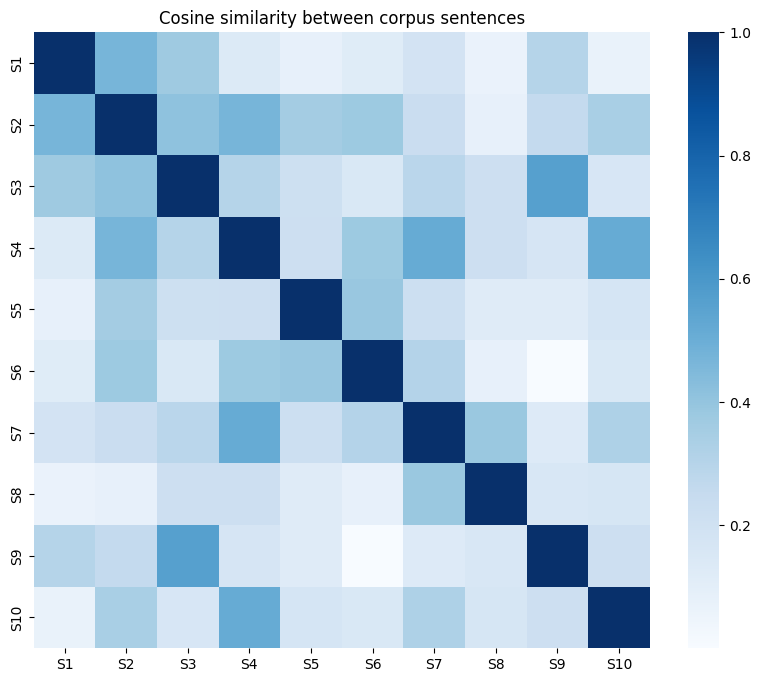

,id,sentence
0,S1,Ashi is working on a RAG project to ground LLM...
1,S2,Ashi is creating embeddings for PDF chunks and...
2,S3,RAG retrieves top-k similar document chunks be...
3,S4,FAISS is an in-memory library for fast similar...
4,S5,Chroma is a developer-friendly local vector st...
5,S6,Pinecone is a managed cloud vector database wi...
6,S7,Weaviate supports hybrid search that blends BM...
7,S8,Traditional keyword search may miss meaning wh...
8,S9,Chunking with overlap helps preserve context a...
9,S10,Embedding vectors are compared using cosine si...


In [7]:
sim_mat = cosine_similarity(corpus_vecs, corpus_vecs)
plt.figure(figsize=(10, 8))
sns.heatmap(sim_mat, cmap='Blues', square=True,
            xticklabels=[f'S{i+1}' for i in range(len(corpus))],
            yticklabels=[f'S{i+1}' for i in range(len(corpus))])
plt.title('Cosine similarity between corpus sentences')
plt.show()

pd.DataFrame({'id':[f'S{i+1}' for i in range(len(corpus))], 'sentence': corpus})


## Example 2 — Mini RAG retrieval using FAISS (local)

We’ll simulate a small RAG pipeline:
1. Create a mini ‘document’
2. Chunk it
3. Embed chunks
4. Index vectors (FAISS)
5. Retrieve top-k chunks for a question

> Note: This is retrieval-only. In real RAG, you would pass the retrieved chunks as context to an LLM.

In [8]:
doc = (
    'Ashi is working on a RAG project. She ingests PDF policies and FAQs, then chunks them into smaller passages. '
    'Each chunk is converted into an embedding vector. These vectors are stored in a vector database like FAISS, Chroma, Pinecone, or Weaviate. '
    'When a user asks a question, the question is embedded and compared to stored chunk vectors using cosine similarity or L2 distance. '
    'The system retrieves the top-k most relevant chunks and sends them to the language model as grounding context. '
    'This reduces hallucinations and helps the model answer using enterprise knowledge.'
)

chunks = chunk_text(doc, chunk_size=180, overlap=40)
pd.DataFrame({'chunk_id': [f'C{i+1}' for i in range(len(chunks))], 'text': chunks})


,chunk_id,text
0,C1,Ashi is working on a RAG project. She ingests ...
1,C2,embedding vector. These vectors are stored in...
2,C3,question is embedded and compared to stored c...
3,C4,ant chunks and sends them to the language mode...


In [9]:
chunk_vecs = embed_texts(chunks, normalize=True).astype('float32')
dim = chunk_vecs.shape[1]
print('Chunk vectors:', chunk_vecs.shape, 'dim=', dim)


Chunk vectors: (4, 384) dim= 384


In [10]:
# FAISS demo
try:
    import faiss
except Exception as e:
    faiss = None
    print('⚠️ FAISS not available. Install faiss-cpu and rerun. Error:', e)

if faiss is not None:
    # With normalized vectors, inner product == cosine similarity
    index = faiss.IndexFlatIP(dim)
    index.add(chunk_vecs)
    print('FAISS ntotal:', index.ntotal)


FAISS ntotal: 4


In [11]:
question = 'Why does RAG reduce hallucinations?'
qv = embed_texts([question], normalize=True).astype('float32')

if faiss is None:
    print('Install faiss-cpu to run retrieval.')
else:
    scores, idx = index.search(qv, k=3)
    results = []
    for rank, (i, s) in enumerate(zip(idx[0], scores[0]), start=1):
        results.append({'rank': rank, 'score': float(s), 'chunk_id': f'C{i+1}', 'chunk_text': chunks[i]})
    pd.DataFrame(results)


### A simple ‘answer’ builder (no LLM)

To keep this notebook self-contained, we’ll create a tiny extractive answer: concatenate the retrieved chunks.

In production, you would build a prompt like:
- **System:** You are a helpful assistant. Answer only from context.
- **Context:** <retrieved chunks>
- **User:** <question>

In [12]:
def build_context_answer(retrieved_chunks):
    return ' '.join([c.strip() for c in retrieved_chunks])

if faiss is not None:
    retrieved = [chunks[i] for i in idx[0]]
    print('QUESTION:', question)
    print('--- RETRIEVED CONTEXT ---')
    print(build_context_answer(retrieved))


QUESTION: Why does RAG reduce hallucinations?
--- RETRIEVED CONTEXT ---
ant chunks and sends them to the language model as grounding context. This reduces hallucinations and helps the model answer using enterprise knowledge. Ashi is working on a RAG project. She ingests PDF policies and FAQs, then chunks them into smaller passages. Each chunk is converted into an embedding vector. These vectors are sto question is embedded and compared to stored chunk vectors using cosine similarity or L2 distance. The system retrieves the top-k most relevant chunks and sends them to the languag


## 3) Vector store option A — Chroma (local)

Chroma is convenient for prototyping and can store **documents + embeddings + metadata**.
Below we add our corpus with precomputed embeddings (so Chroma doesn’t need to run its own embedding model).

In [ ]:
try:
    import chromadb
except Exception as e:
    chromadb = None
    print('⚠️ chromadb not available. Install chromadb and rerun. Error:', e)

if chromadb is not None:
    client = chromadb.Client()  # in-memory
    collection = client.get_or_create_collection('rag_corpus_demo')
    # Add docs with explicit embeddings
    ids = [f'doc{i+1}' for i in range(len(corpus))]
    metadatas = [{'source':'training_demo', 'topic':'rag'} for _ in corpus]
    collection.add(ids=ids, documents=corpus, metadatas=metadatas, embeddings=corpus_vecs.tolist())
    print('Chroma count:', collection.count())


In [ ]:
if chromadb is None:
    print('Install chromadb to run this section.')
else:
    q = 'Which vector database supports hybrid keyword + vector search?'
    qv = embed_texts([q], normalize=True)[0].tolist()
    res = collection.query(query_embeddings=[qv], n_results=3, include=['documents','metadatas','distances'])
    res


In [ ]:
%pip install -q chromadb

## 4) Vector store option B — Pinecone (managed, optional)

⚠️ This section requires a Pinecone account + API key, and creating an index with the correct dimension.

We keep it **optional** for participants; it’s here to show how the same embeddings are upserted and queried in a managed service.

## 5) Vector store option C — Weaviate (hybrid search, optional)

Weaviate can do **hybrid retrieval** (keyword BM25 + vector).

⚠️ This section is optional because it requires a running Weaviate instance (local Docker or cloud).

## Hands-on 1 (participants) — Expand the corpus + analyze similarity

### Task
1. Add **8–10 new sentences** to the `corpus` list (mix synonyms + different wording).
2. Recompute embeddings.
3. Plot a new similarity heatmap.
4. Identify **clusters** (which sentences are closest, and why?).

**Deliverable:** A screenshot of the heatmap + 3 bullet observations.

In [ ]:
# TODO (Hands-on 1): Add more sentences
corpus_extra = [
    # 'Add your sentence 1',
    # 'Add your sentence 2',
    # ...
]

# TODO: Combine + embed
corpus2 = corpus + corpus_extra
# corpus2_vecs = embed_texts(corpus2, normalize=True)

# TODO: Heatmap
# sim2 = cosine_similarity(corpus2_vecs, corpus2_vecs)
# plt.figure(figsize=(10, 8))
# sns.heatmap(sim2, cmap='Blues', square=True)
# plt.title('Cosine similarity — expanded corpus')
# plt.show()


## Hands-on 2 (participants) — Build a tiny RAG retriever (FAISS or Chroma)

### Task
You will build retrieval for a mini ‘knowledge base’ and answer questions using retrieved context.

1. Create a mini knowledge base text (5–10 lines) on any domain (HR policy, Azure basics, travel policy, etc.).
2. Chunk it (choose chunk size + overlap).
3. Embed chunks.
4. Store in **FAISS** (or **Chroma**) and retrieve top-3 for a question.
5. Build a prompt template (even if you don’t call an LLM).

- **Deliverable:** Print top-3 retrieved chunks + your final prompt template.

In [ ]:
# TODO (Hands-on 2): Create your own mini knowledge base
kb_text = '''
(1) ...
(2) ...
(3) ...
'''

# TODO: Chunk
# kb_chunks = chunk_text(kb_text, chunk_size=200, overlap=50)
# kb_vecs = embed_texts(kb_chunks, normalize=True).astype('float32')

# TODO: Index with FAISS OR add to Chroma
# If using FAISS (normalized vectors):
# import faiss
# dim = kb_vecs.shape[1]
# kb_index = faiss.IndexFlatIP(dim)
# kb_index.add(kb_vecs)

# TODO: Query
# q = 'Write your question here'
# qv = embed_texts([q], normalize=True).astype('float32')
# scores, idx = kb_index.search(qv, k=3)
# print('Top chunks:')
# for i in idx[0]:
#     print('-', kb_chunks[i])

# TODO: Prompt template
# prompt = f"""You are an assistant. Answer ONLY using the context.

Context:
{...}

Question: {q}
Answer:"""
# print(prompt)


---

## Recap
- Embeddings turn text into vectors so *meaning* becomes *distance*.
- RAG uses embeddings to retrieve relevant chunks (Top-k) before generation.
- FAISS and Chroma are great for local demos; Pinecone/Weaviate represent managed/production-style options.
